<strong>Import Necessary Libraries</strong><br>
Imports all essential Python libraries required for data manipulation, numerical operations, data visualization, and building machine learning models using Scikit-Learn.

In [1]:
# Core Data Libraries
import pandas as pd
import numpy as np

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Libraries (Scikit-Learn)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Styling for plots
sns.set(style="whitegrid")

<strong> Load and Inspect the Dataset </strong><br>Loads the CSV file into a Pandas DataFrame and checks its structure, dimensions, data types, and missing values to ensure the data is clean and ready for analysis.

In [4]:
# Load the dataset (update path if running locally)
df = pd.read_csv('D:\Projects\Python_projects\Machine_Learning\CodeAlpha\Iris Flower Classification\Iris.csv')

# Display the first 5 rows
print("First 5 rows of the dataset:")
display(df.head())

# Check dataset information and missing values
print("\nDataset Info:")
df.info()

# Summary statistics
print("\nSummary Statistics:")
display(df.describe())

First 5 rows of the dataset:


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa



Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 9.1 KB

Summary Statistics:


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


<strong>Exploratory Data Analysis (EDA) & Visualization</strong><br>
Visualizes the relationships between different features (sepal and petal dimensions) and the target classes (Species). This helps us understand which features are most useful for distinguishing between flower species.

C:\Users\hlifah\AppData\Local\Temp\ipykernel_14372\1743398429.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Species', data=df, palette='Set2')


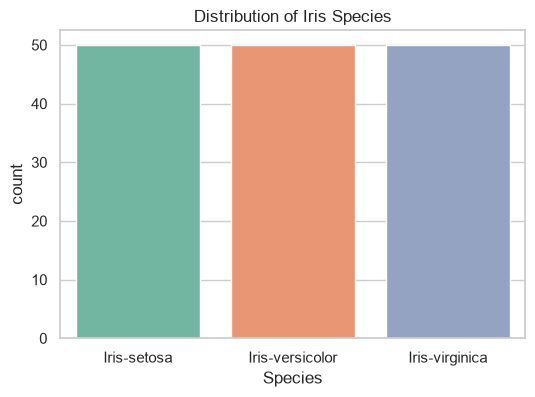

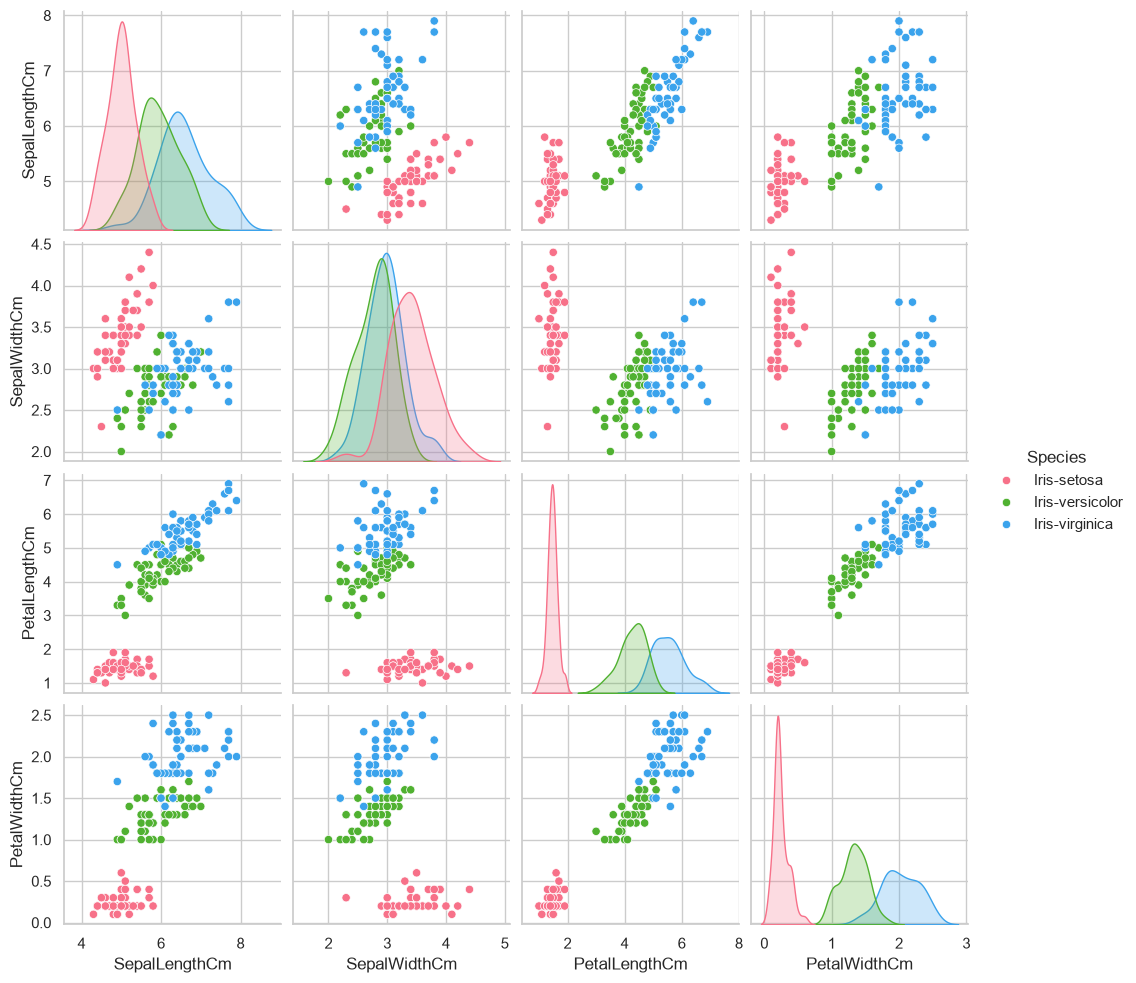

In [5]:
# Count plot for species distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='Species', data=df, palette='Set2')
plt.title('Distribution of Iris Species')
plt.show()

# Pairplot to visualize feature correlations across species
sns.pairplot(df.drop('Id', axis=1), hue='Species', palette='husl')
plt.show()

<strong>Data Preprocessing & Feature Selection</strong><br>Prepares the data for machine learning. We drop the Id column since it contains no predictive value, separate our input features ($X$) from our target label ($Y$), and encode the categorical species names into numerical values.

In [6]:
# Drop the 'Id' column as it is just an index
df_cleaned = df.drop(columns=['Id'])

# Separate Features (X) and Target (y)
X = df_cleaned.drop(columns=['Species'])
y = df_cleaned['Species']

# Encode target labels into numbers (e.g., setosa -> 0, versicolor -> 1, virginica -> 2)
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

print("Features shape:", X.shape)
print("Target shape:", y_encoded.shape)

Features shape: (150, 4)
Target shape: (150,)


<stong>Train-Test Split</strong><br>Splits the dataset into a training set (used to teach the machine learning model patterns) and a testing set (used to evaluate how well the model generalizes to unseen data). We typically use an 80-20 split.

In [7]:
# Split data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Training set samples: {X_train.shape[0]}")
print(f"Testing set samples: {X_test.shape[0]}")

Training set samples: 120
Testing set samples: 30


<stong>Model Training</strong><br>Initializes a classification algorithm—in this case, a Random Forest Classifier (an ensemble model robust against overfitting)—and trains it using the training dataset (X_train and y_train).

In [8]:
# Initialize the Random Forest Classifier
model = RandomForestClassifier(random_state=42)

# Train (fit) the model on the training data
model.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


<strong>Model Evaluation & Performance Metrics</strong><br>Uses the trained model to make predictions on the unseen test data (X_test). We evaluate its performance using Accuracy, a Confusion Matrix, and a detailed Classification Report (Precision, Recall, and F1-score).

Model Accuracy: 90.00%

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.82      0.90      0.86        10
 Iris-virginica       0.89      0.80      0.84        10

       accuracy                           0.90        30
      macro avg       0.90      0.90      0.90        30
   weighted avg       0.90      0.90      0.90        30



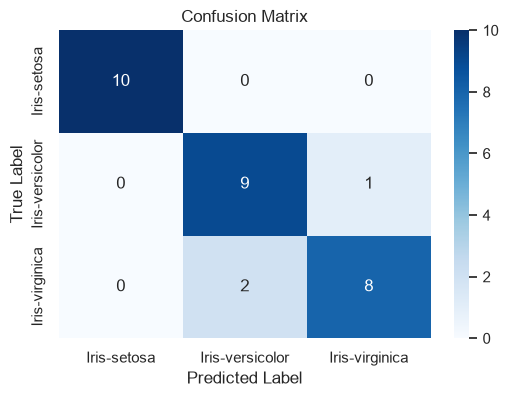

In [9]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%\n")

# Detailed Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=encoder.classes_))

# Confusion Matrix Visualization
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=encoder.classes_, 
            yticklabels=encoder.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

Testing trained model

In [10]:
# Define custom measurements: [SepalLengthCm, SepalWidthCm, PetalLengthCm, PetalWidthCm]
# Example: Let's test a flower with features similar to a Virginica or Setosa
sample_flower = [[6.7, 3.0, 5.2, 2.3]]

# Predict the species using our trained model
predicted_class_encoded = model.predict(sample_flower)

# Convert the numerical prediction back to the original species name
predicted_species = encoder.inverse_transform(predicted_class_encoded)

print(f"The predicted species for the custom measurement is: **{predicted_species[0]}**")

The predicted species for the custom measurement is: **Iris-virginica**


C:\Users\hlifah\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [1]:
%pwd

'C:\\Users\\hlifah'